TEST 2

In [ ]:
!pip -q install transformers accelerate sentence-transformers umap-learn plotly

In [ ]:
import os
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

###Paths

INPUTS = [
    "jawaher_MSA_examples_long_renamed.csv",
    "jawaher_MSA_examples_long_with_literal.csv",
]

INPUT_CSV = next((p for p in INPUTS if Path(p).exists()), INPUTS[0])

QWEN_CSV   = "jawaher_qwen_clean.csv"
SCORED_CSV = "jawaher_qwen_scored.csv"
MASK_CSV   = "jawaher_qwen_masking.csv"
IMP_CSV    = "jawaher_qwen_masking_importance.csv"

### LOAD MODEL
QWEN_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
EMBED_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device)
print("Input CSV:", INPUT_CSV)

In [ ]:
### Clean model outputs by removing prefixes and formatting noise + DEtect suspicious output +Score output quality

ARABIC_CHAR_RE = re.compile(r"[\u0600-\u06FF]")
ASCII_LETTER_RE = re.compile(r"[A-Za-z]")

def safe_str(x):
    return "" if pd.isna(x) else str(x)

def normalize_space(s: str) -> str:
    s = safe_str(s)
    s = s.replace("\u00a0", " ")
    return re.sub(r"\s+", " ", s).strip()

_PREFIX_PATTERNS = [
    r"^\s*english\s*(translation)?\s*:\s*",
    r"^\s*translation\s*:\s*",
    r"^\s*translated\s*text\s*:\s*",
    r"^\s*the\s+english\s+translation\s+is\s*:\s*",
    r"^\s*here\s+is\s+the\s+english\s+translation\s*:\s*",
    r"^\s*here\s+is\s+the\s+translation\s*:\s*",
    r"^\s*output\s*:\s*",
    r"^\s*answer\s*:\s*",
]

def strip_english_prefix_flag(s: str) -> int:
    raw = safe_str(s)
    return int(bool(re.match(r"\s*(english\s*(translation)?|translation|output|answer)\s*:", raw, flags=re.IGNORECASE)))

def keep_best_content_line(s: str) -> str:
    parts = [normalize_space(p) for p in safe_str(s).splitlines() if normalize_space(p)]
    if not parts:
        return ""
    bad_starts = (
        "sure", "certainly", "of course", "here is", "the english translation is",
        "translation", "english translation", "output", "answer"
    )
    for p in parts:
        low = p.lower()
        if not any(low.startswith(b) for b in bad_starts):
            return p
    return parts[0]

def clean_english_output(s: str) -> str:
    s = safe_str(s).strip()
    s = s.replace("“", '"').replace("”", '"').replace("’", "'").replace("`", "'")
    s = keep_best_content_line(s)
    s = normalize_space(s)

    prev = None
    while prev != s:
        prev = s
        for pat in _PREFIX_PATTERNS:
            s = re.sub(pat, "", s, flags=re.IGNORECASE)
        s = re.sub(r"^\s*[-–•]\s*", "", s)
        s = re.sub(r'^(["\'])+(.*?)(["\'])+$', r"\2", s)
        s = normalize_space(s)

    s = re.sub(r"^\s*(Sure|Certainly|Of course)[,!: -]*", "", s, flags=re.IGNORECASE)
    s = normalize_space(s)
    return s

def contains_arabic(text: str) -> int:
    return int(bool(ARABIC_CHAR_RE.search(safe_str(text))))

def ascii_letter_ratio(text: str) -> float:
    text = safe_str(text)
    if not text:
        return 0.0
    return len(ASCII_LETTER_RE.findall(text)) / max(len(text), 1)

def suspicious_translation_reasons(text: str):
    text = clean_english_output(text)
    reasons = []
    wc = len(text.split())

    if not text:
        reasons.append("empty")
    if contains_arabic(text):
        reasons.append("contains_arabic")
    if wc <= 1:
        reasons.append("too_short")
    if wc >= 45:
        reasons.append("too_long")
    if ":" in text[:20]:
        reasons.append("leading_colon_meta")
    if ascii_letter_ratio(text) < 0.35:
        reasons.append("low_ascii_letter_ratio")
    return reasons

def is_suspicious_translation(text: str) -> int:
    return int(len(suspicious_translation_reasons(text)) > 0)

def translation_quality_score(text: str) -> int:
    #Strongly penalize Arabic leakage and very suspicious formatting

    text = clean_english_output(text)
    reasons = suspicious_translation_reasons(text)
    score = 100
    if "contains_arabic" in reasons:
        score -= 50
    score -= 12 * ("empty" in reasons)
    score -= 10 * ("too_short" in reasons)
    score -= 8 * ("too_long" in reasons)
    score -= 8 * ("leading_colon_meta" in reasons)
    score -= 12 * ("low_ascii_letter_ratio" in reasons)
    score -= 2 * strip_english_prefix_flag(text)
    return score


In [ ]:
##### Arabic normalization Helpers
# Normalize Arabic text to make idiom matching more robust despite diacritics, punctuation, or orthographic variation


AR_PUNCT = r"""!"#$%&'()*+,\-./:;<=>?@[\]^_`{|}~،؛؟«»…"""
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]")
TATWEEL_RE = re.compile(r"\u0640")

def normalize_arabic_for_match(text: str) -> str:
    text = safe_str(text)
    text = unicodedata.normalize("NFKC", text)
    text = DIACRITICS_RE.sub("", text)
    text = TATWEEL_RE.sub("", text)

    text = re.sub(r"[أإآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")
    text = text.replace("ة", "ه")

    return normalize_space(text)

def strip_edge_punct(token: str) -> str:
    return token.strip(AR_PUNCT + " ")

def ws_tokens(text: str):
    return [t for t in safe_str(text).split() if t.strip()]

def normalized_ws_tokens(text: str):
    toks = ws_tokens(text)
    norm = [normalize_arabic_for_match(strip_edge_punct(t)) for t in toks]
    return toks, norm



###### MAPPING: find the exact idiom span inside the full sentence
def find_idiom_span_in_sentence(sentence: str, idiom: str):
    sent_raw, sent_norm = normalized_ws_tokens(sentence)
    idi_raw, idi_norm = normalized_ws_tokens(idiom)

    idi_norm = [t for t in idi_norm if t]
    if not idi_norm:
        return None

    m = len(idi_norm)
    for i in range(len(sent_norm) - m + 1):
        if sent_norm[i:i+m] == idi_norm:
            return i, i + m
    return None


###### Remove one idiom word from the sentence at a time
def mask_one_idiom_word(sentence: str, idiom: str, target_word: str):
    sentence = normalize_space(sentence)
    target_norm = normalize_arabic_for_match(strip_edge_punct(target_word))

    sent_raw, sent_norm = normalized_ws_tokens(sentence)
    span = find_idiom_span_in_sentence(sentence, idiom)

    if span is not None:
        start, end = span
        for j in range(start, end):
            if sent_norm[j] == target_norm:
                masked_tokens = sent_raw[:j] + sent_raw[j+1:]
                return " ".join(masked_tokens), True

    for j in range(len(sent_norm)):
        if sent_norm[j] == target_norm:
            masked_tokens = sent_raw[:j] + sent_raw[j+1:]
            return " ".join(masked_tokens), False

    return sentence, False



### Extract unique normalized idiom words
def idiom_words_from_idiom(idiom: str):
    raw, norm = normalized_ws_tokens(idiom)
    words, seen = [], set()
    for r, n in zip(raw, norm):
        if n and n not in seen:
            words.append(r)
            seen.add(n)
    return words

In [ ]:
#### Helper functions for cosine similarity/embedding normalization

def l2_normalize(x: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True) + 1e-12
    return x / norms

def cosine_rows(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.sum(a * b, axis=1)


#### Data loader
def load_jawaher(input_csv=INPUT_CSV):
    df = pd.read_csv(input_csv)

    rename_map = {
        "Proverbs": "idiom",
        "Ar_example_sentence": "source_sentence",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})

    required_cols = [
        "idiom",
        "source_sentence",
        "En_Literal",
        "En_Equivalent",
        "En_Explanation",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    assert not missing, f"Missing columns: {missing}"

    df["idiom"] = df["idiom"].fillna("").astype(str)
    df["source_sentence"] = df["source_sentence"].fillna("").astype(str)
    df = df[df["source_sentence"].str.strip() != ""].copy()
    df.reset_index(drop=True, inplace=True)
    return df

print("Setup complete.")

Setup complete.


In [ ]:
#### Load and check data

df = load_jawaher(INPUT_CSV)

print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df[["idiom", "source_sentence", "En_Literal", "En_Equivalent", "En_Explanation"]].head(5))


Rows: 280
Columns: ['idiom', 'Ar_Explanation', 'En_Explanation', 'En_Equivalent', 'Variety', '_row_id', 'orig_row_id', 'lev_row_id', 'Ar_example_sentences', 'source_sentence', 'example_id', 'En_Literal']


,idiom,source_sentence,En_Literal,En_Equivalent,En_Explanation
0,آخر الحياة الموت,تذكر أن النهاية واحدة، آخر الحياة الموت.,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",A wisdom that has become a proverb about not c...
1,آخر الحياة الموت,لا تضيّع عمرك في خصومات تافهة، آخر الحياة الموت.,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",A wisdom that has become a proverb about not c...
2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...
3,أتبع من الظل.,منذ وصل إلى المكان وهو أتبع من الظل، كأنه لا ي...,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...
4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,More following than the shadow.,Sticks to them like a shadow.,The proverb refers to someone who follows anot...


In [ ]:
##### Baselinr Qwen Translation
# Generate English Translations for the original Arabic sentences
# Suspicious outputs are retried with  a stricter prompt
#the cleaner version is kept for downstream scoring

df = load_jawaher(INPUT_CSV)

tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    torch_dtype=dtype,
    device_map="auto" if device == "cuda" else None
)
if device == "cpu":
    model = model.to(device)
model.eval()

SYSTEM_MSG = "You are a professional Arabic-to-English translator."


### Build chat prompts
def make_messages(ar_sentence: str, strict: bool = False):
    if not strict:
        user_prompt = (
            "Translate the following Arabic sentence into natural English.\n"
            "Return ONLY the English translation.\n"
            "Do not add labels, bullets, explanations, or quotation marks.\n\n"
            f"Arabic sentence:\n{ar_sentence}"
        )
    else:
        #this version is used only when initial outputs look suspicious
        user_prompt = (
            "Translate the following Arabic sentence into ONE natural English sentence.\n"
            "Return ONLY the final English translation.\n"
            "Do not include Arabic script.\n"
            "Do not add labels, bullets, explanations, notes, quotation marks, or multiple options.\n"
            "The answer must be English only.\n\n"
            f"Arabic sentence:\n{ar_sentence}"
        )
    return [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user", "content": user_prompt},
    ]


# Generate translations in batches for efficiency
def translate_qwen_batch(sentences, max_new_tokens=80, strict: bool = False):
    prompts = []
    for s in sentences:
        msgs = make_messages(safe_str(s), strict=strict)
        prompt = tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=True
        )
        prompts.append(prompt)

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
        )
    # Decode only the newly generated portion of the sequence
    decoded = []
    input_lengths = inputs["attention_mask"].sum(dim=1).tolist()
    for i, out_ids in enumerate(outputs):
        gen_ids = out_ids[int(input_lengths[i]):]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True)
        decoded.append(text)

    return decoded

#Compile initial vs strict retry outputs
# Keep whichever one has better formatting/quality score
def choose_better_translation(raw_a: str, raw_b: str):
    cand_a = clean_english_output(raw_a)
    cand_b = clean_english_output(raw_b)

    score_a = translation_quality_score(cand_a)
    score_b = translation_quality_score(cand_b)

    if score_b > score_a:
        return cand_b, "strict_retry"
    return cand_a, "initial"

sentences = df["source_sentence"].astype(str).tolist()
batch_size = 8 if device == "cuda" else 2

initial_raw = []
for i in tqdm(range(0, len(sentences), batch_size), desc="Initial Qwen translation"):
    batch = sentences[i:i+batch_size]
    initial_raw.extend(translate_qwen_batch(batch, strict=False))

df["qwen_translation_initial_raw"] = initial_raw
df["qwen_translation_initial_clean"] = df["qwen_translation_initial_raw"].apply(clean_english_output)
df["qwen_initial_suspicious"] = df["qwen_translation_initial_clean"].apply(is_suspicious_translation)
df["qwen_initial_reasons"] = df["qwen_translation_initial_clean"].apply(lambda s: ";".join(suspicious_translation_reasons(s)))

flag_idx = df.index[df["qwen_initial_suspicious"] == 1].tolist()
strict_raw_map = {}

if flag_idx:
    retry_sentences = df.loc[flag_idx, "source_sentence"].astype(str).tolist()
    retry_out = []
    for i in tqdm(range(0, len(retry_sentences), batch_size), desc="Strict retry for suspicious outputs"):
        batch = retry_sentences[i:i+batch_size]
        retry_out.extend(translate_qwen_batch(batch, strict=True))
    strict_raw_map = dict(zip(flag_idx, retry_out))

final_translations = []
translation_source = []

for idx, row in df.iterrows():
    raw_initial = row["qwen_translation_initial_raw"]
    raw_retry = strict_raw_map.get(idx, "")
    best_text, best_src = choose_better_translation(raw_initial, raw_retry) if raw_retry else (clean_english_output(raw_initial), "initial")
    final_translations.append(best_text)
    translation_source.append(best_src)

df["qwen_translation"] = final_translations
df["qwen_translation_source"] = translation_source
df["qwen_contains_arabic"] = df["qwen_translation"].apply(contains_arabic)
df["qwen_is_suspicious"] = df["qwen_translation"].apply(is_suspicious_translation)
df["qwen_suspicion_reasons"] = df["qwen_translation"].apply(lambda s: ";".join(suspicious_translation_reasons(s)))

df.to_csv(QWEN_CSV, index=False)

print("Saved:", QWEN_CSV)
print("Initial suspicious rows:", int(df["qwen_initial_suspicious"].sum()))
print("Rows improved by strict retry:", int((df["qwen_translation_source"] == "strict_retry").sum()))
print("Final rows containing Arabic:", int(df["qwen_contains_arabic"].sum()))
print("Final suspicious rows:", int(df["qwen_is_suspicious"].sum()))

display(
    df[
        [
            "idiom",
            "source_sentence",
            "qwen_translation",
            "qwen_translation_source",
            "qwen_contains_arabic",
            "qwen_is_suspicious",
            "qwen_suspicion_reasons",
        ]
    ].head(10)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Initial Qwen translation:   0%|          | 0/35 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Strict retry for suspicious outputs:   0%|          | 0/2 [00:00<?, ?it/s]

Saved: jawaher_qwen_clean.csv
Initial suspicious rows: 10
Rows improved by strict retry: 10
Final rows containing Arabic: 1
Final suspicious rows: 2


,idiom,source_sentence,qwen_translation,qwen_translation_source,qwen_contains_arabic,qwen_is_suspicious,qwen_suspicion_reasons
0,آخر الحياة الموت,تذكر أن النهاية واحدة، آخر الحياة الموت.,"The end is one, death is the last life.",initial,0,0,
1,آخر الحياة الموت,لا تضيّع عمرك في خصومات تافهة، آخر الحياة الموت.,Don't waste your life on silly bargains; they ...,initial,0,0,
2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,"He followed closely behind, never leaving him ...",initial,0,0,
3,أتبع من الظل.,منذ وصل إلى المكان وهو أتبع من الظل، كأنه لا ي...,"The moment he arrived at the place, he was fol...",initial,0,0,
4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,We laughed when we saw him follow behind us al...,initial,0,0,
5,أحْسِنْ إلى الناس تستعبد قلوبهم.,أحسن إلى الناس تستعبد قلوبهم، فالكلمة الطيبة ل...,Be kind to people and they will love you back;...,initial,0,0,
6,أحْسِنْ إلى الناس تستعبد قلوبهم.,كان يعامل الجميع باحترام، مؤمنًا بأن أحسن إلى ...,"He treated everyone with respect, confident th...",initial,0,0,
7,أحضر الناس جوابًا من لم يغضب,حاول أن يهدأ قبل الرد، فـأحضر الناس جوابًا من ...,"Before responding, he tried to calm down, and ...",initial,0,0,
8,أحضر الناس جوابًا من لم يغضب,عندما كتم غضبه استطاع أن يجيب بحكمة، أحضر النا...,"When he kept his anger to himself, he was able...",initial,0,0,
9,أحلام العصافير.,كان يتحدث عن مشاريع خيالية، أحلام العصافير لا ...,"He talked about fantastic projects, fairy tale...",initial,0,0,


In [ ]:
############## BASELINE SCORING
# Compare each Qwen Translation to literal and figurative anchors usging multilangual sentence embeddings
if not Path(QWEN_CSV).exists():
    raise FileNotFoundError(
        f"{QWEN_CSV} was not found. Run CELL 3 first to generate Qwen translations."
    )

df = pd.read_csv(QWEN_CSV)



required = ["qwen_translation", "En_Literal", "En_Equivalent", "En_Explanation"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

embedder = SentenceTransformer(EMBED_MODEL, device=device)

#clean both model outputs and anchor texts before embedding, this reduces noide from prefixes or formatting artifacts
df["qwen_had_prefix"] = df["qwen_translation"].apply(strip_english_prefix_flag)
df["qwen_translation_clean"] = df["qwen_translation"].apply(clean_english_output)
df["En_Literal_clean"] = df["En_Literal"].apply(clean_english_output)
df["En_Equivalent_clean"] = df["En_Equivalent"].apply(clean_english_output)
df["En_Explanation_clean"] = df["En_Explanation"].apply(clean_english_output)

df["qwen_contains_arabic"] = df["qwen_translation_clean"].apply(contains_arabic)
df["qwen_is_suspicious"] = df["qwen_translation_clean"].apply(is_suspicious_translation)
df["qwen_suspicion_reasons"] = df["qwen_translation_clean"].apply(lambda s: ";".join(suspicious_translation_reasons(s)))
df["qwen_clean_for_analysis"] = ((df["qwen_contains_arabic"] == 0) & (df["qwen_is_suspicious"] == 0)).astype(int)

qwen_out = df["qwen_translation_clean"].tolist()
lit = df["En_Literal_clean"].tolist()
eqv = df["En_Equivalent_clean"].tolist()
exp = df["En_Explanation_clean"].tolist()

### Embed baseline translation and reference anchors
all_texts = qwen_out + lit + eqv + exp
emb = embedder.encode(all_texts, convert_to_numpy=True, show_progress_bar=True)
emb = l2_normalize(emb)

n = len(df)
emb_qwen = emb[0:n]
emb_lit  = emb[n:2*n] #lit anchor
emb_eqv  = emb[2*n:3*n]
emb_exp  = emb[3*n:4*n]

#fig anchor = average of equivalent + explanaiton
emb_fig = l2_normalize((emb_eqv + emb_exp) / 2.0)


#compute cosine similarities to literal and figurative meanings
#delta_qwen : core semantic score
# delta_qwen > 0 => closer to fig meaning
# delta_qwen < 0 => closer to lit meaning
df["sim_lit_qwen"] = cosine_rows(emb_qwen, emb_lit)
df["sim_fig_qwen"] = cosine_rows(emb_qwen, emb_fig)
df["delta_qwen"] = df["sim_fig_qwen"] - df["sim_lit_qwen"]
df["is_literal_qwen"] = (df["sim_lit_qwen"] >= df["sim_fig_qwen"]).astype(int)

df.to_csv(SCORED_CSV, index=False)

all_literal_rate = df["is_literal_qwen"].mean()
clean_subset = df[df["qwen_clean_for_analysis"] == 1].copy()
clean_literal_rate = clean_subset["is_literal_qwen"].mean() if len(clean_subset) else np.nan

print("Saved:", SCORED_CSV)
print("Qwen literal rate (all rows):", round(all_literal_rate, 3))
print("Qwen figurative rate (all rows):", round(1 - all_literal_rate, 3))
print("Rows with obvious translation prefix before cleaning:", int(df["qwen_had_prefix"].sum()))
print("Rows containing Arabic after cleaning:", int(df["qwen_contains_arabic"].sum()))
print("Rows flagged suspicious after cleaning:", int(df["qwen_is_suspicious"].sum()))
print("Rows clean for analysis:", int(df["qwen_clean_for_analysis"].sum()))
print("Qwen literal rate (clean rows only):", None if pd.isna(clean_literal_rate) else round(clean_literal_rate, 3))

display(
    df[
        [
            "idiom",
            "source_sentence",
            "qwen_translation",
            "qwen_translation_clean",
            "qwen_contains_arabic",
            "qwen_is_suspicious",
            "qwen_clean_for_analysis",
            "En_Literal_clean",
            "En_Equivalent_clean",
            "sim_lit_qwen",
            "sim_fig_qwen",
            "delta_qwen",
            "is_literal_qwen",
        ]
    ].head(10)
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Saved: jawaher_qwen_scored.csv
Qwen literal rate (all rows): 0.636
Qwen figurative rate (all rows): 0.364
Rows with obvious translation prefix before cleaning: 0
Rows containing Arabic after cleaning: 1
Rows flagged suspicious after cleaning: 2
Rows clean for analysis: 278
Qwen literal rate (clean rows only): 0.637


,idiom,source_sentence,qwen_translation,qwen_translation_clean,qwen_contains_arabic,qwen_is_suspicious,qwen_clean_for_analysis,En_Literal_clean,En_Equivalent_clean,sim_lit_qwen,sim_fig_qwen,delta_qwen,is_literal_qwen
0,آخر الحياة الموت,تذكر أن النهاية واحدة، آخر الحياة الموت.,"The end is one, death is the last life.","The end is one, death is the last life.",0,0,1,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",0.881967,0.425928,-0.456039,1
1,آخر الحياة الموت,لا تضيّع عمرك في خصومات تافهة، آخر الحياة الموت.,Don't waste your life on silly bargains; they ...,Don't waste your life on silly bargains; they ...,0,0,1,The end of life is death.,"Live life to its fullest; Tempus fugit, utere.",0.508872,0.364613,-0.144259,1
2,أتبع من الظل.,هو أتبع من الظل، لا يتركه لحظة واحدة.,"He followed closely behind, never leaving him ...","He followed closely behind, never leaving him ...",0,0,1,More following than the shadow.,Sticks to them like a shadow.,0.191868,0.405189,0.213320,0
3,أتبع من الظل.,منذ وصل إلى المكان وهو أتبع من الظل، كأنه لا ي...,"The moment he arrived at the place, he was fol...","The moment he arrived at the place, he was fol...",0,0,1,More following than the shadow.,Sticks to them like a shadow.,0.367530,0.403202,0.035672,0
4,أتبع من الظل.,ضحكنا عندما رأيناه أتبع من الظل طوال اليوم.,We laughed when we saw him follow behind us al...,We laughed when we saw him follow behind us al...,0,0,1,More following than the shadow.,Sticks to them like a shadow.,0.313077,0.364588,0.051511,0
5,أحْسِنْ إلى الناس تستعبد قلوبهم.,أحسن إلى الناس تستعبد قلوبهم، فالكلمة الطيبة ل...,Be kind to people and they will love you back;...,Be kind to people and they will love you back;...,0,0,1,Do good to people and you will enslave their h...,Kindness begets kindness.,0.523389,0.715225,0.191836,0
6,أحْسِنْ إلى الناس تستعبد قلوبهم.,كان يعامل الجميع باحترام، مؤمنًا بأن أحسن إلى ...,"He treated everyone with respect, confident th...","He treated everyone with respect, confident th...",0,0,1,Do good to people and you will enslave their h...,Kindness begets kindness.,0.360857,0.515104,0.154247,0
7,أحضر الناس جوابًا من لم يغضب,حاول أن يهدأ قبل الرد، فـأحضر الناس جوابًا من ...,"Before responding, he tried to calm down, and ...","Before responding, he tried to calm down, and ...",0,0,1,The readiest of people with an answer is the o...,"If you stay calm, you are wise, but if you hav...",0.624221,0.497731,-0.126490,1
8,أحضر الناس جوابًا من لم يغضب,عندما كتم غضبه استطاع أن يجيب بحكمة، أحضر النا...,"When he kept his anger to himself, he was able...","When he kept his anger to himself, he was able...",0,0,1,The readiest of people with an answer is the o...,"If you stay calm, you are wise, but if you hav...",0.673928,0.616727,-0.057201,1
9,أحلام العصافير.,كان يتحدث عن مشاريع خيالية، أحلام العصافير لا ...,"He talked about fantastic projects, fairy tale...","He talked about fantastic projects, fairy tale...",0,0,1,The dreams of birds.,pie in the sky.,0.493929,0.324520,-0.169409,1


In [ ]:
##### Helper: suspicious output detection
# Masking can produce unstable generations so we explicitly flag outputs that are empty, malformed or contain arabic


import re
import pandas as pd

ARABIC_RE = re.compile(r"[\u0600-\u06FF]")

def contains_arabic(text: str) -> bool:
    text = "" if pd.isna(text) else str(text)
    return bool(ARABIC_RE.search(text))

def detect_suspicious_translation(text: str):
    """
    Returns:
        is_suspicious (bool), reason (str)
    """
    text = "" if pd.isna(text) else str(text)
    t = text.strip()

    reasons = []

    if not t:
        reasons.append("empty")

    # Arabic leakage
    if contains_arabic(t):
        reasons.append("contains_arabic")

    # Too short
    if len(t.split()) <= 1:
        reasons.append("too_short")

    # Too long for a proverb/example translation
    if len(t.split()) > 60:
        reasons.append("too_long")

    # Repetitive punctuation / odd formatting
    if re.search(r"[!?.,:;]{4,}", t):
        reasons.append("punctuation_noise")

    # Obvious meta-output that slipped through cleaning
    meta_patterns = [
        r"^\s*translation\s*:",
        r"^\s*english\s*translation\s*:",
        r"^\s*the\s+translation\s+is\s*:",
        r"^\s*here\s+is\s+the\s+translation\s*:",
        r"^\s*in\s+english\s*:",
    ]
    for p in meta_patterns:
        if re.search(p, t, flags=re.IGNORECASE):
            reasons.append("meta_prefix")
            break

    # Mostly copied quote-like / weird wrapper output
    if t.count('"') >= 4 or t.count("'") >= 4:
        reasons.append("quote_heavy")

    # Many non-letter symbols
    nonword_ratio = len(re.findall(r"[^\w\s]", t)) / max(len(t), 1)
    if nonword_ratio > 0.20:
        reasons.append("symbol_heavy")

    return (len(reasons) > 0), "|".join(reasons) if reasons else ""

In [ ]:
#### MASKING EXPERIMENT
#Remove one idiom word at a time, regenerate the translation and measure how the output changes relative to the baseline

df = pd.read_csv(SCORED_CSV)

required = [
    "idiom",
    "source_sentence",
    "qwen_translation_clean",
    "En_Literal_clean",
    "En_Equivalent_clean",
    "En_Explanation_clean",
    "delta_qwen",
    "sim_lit_qwen",
    "sim_fig_qwen",
]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# Use the SAME embedding model everywhere
sim_encoder = SentenceTransformer(EMBED_MODEL, device=device)

def cos_sim_text(a: str, b: str) -> float:
    a = clean_english_output(a)
    b = clean_english_output(b)
    if not a or not b:
        return np.nan
    vecs = sim_encoder.encode([a, b], convert_to_numpy=True, normalize_embeddings=True)
    return float(np.dot(vecs[0], vecs[1]))

records = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Masking idiom words"):
    idiom = safe_str(row["idiom"])
    sent = safe_str(row["source_sentence"])
    base_qwen = clean_english_output(row["qwen_translation_clean"])

    lit = clean_english_output(row["En_Literal_clean"])
    eqv = clean_english_output(row["En_Equivalent_clean"])
    exp = clean_english_output(row["En_Explanation_clean"])

    words = idiom_words_from_idiom(idiom)
    if len(words) < 2:
        continue

    base_sim_lit = float(row["sim_lit_qwen"])
    base_sim_fig = float(row["sim_fig_qwen"])
    base_delta = float(row["delta_qwen"])

    for w in words:
        masked_sentence, found_exact = mask_one_idiom_word(sent, idiom, w)

        masked_qwen = translate_qwen_batch([masked_sentence])[0]
        masked_qwen_raw = safe_str(masked_qwen)
        masked_qwen = clean_english_output(masked_qwen)

        # quality flags
        masked_has_arabic = contains_arabic(masked_qwen)
        masked_is_suspicious, masked_suspicious_reason = detect_suspicious_translation(masked_qwen)

        # Drift: base vs masked translation : semantic distance between baseline and masked outputs
        # higher drift means the removed word had a stronger effect
        drift_qwen = 1.0 - cos_sim_text(base_qwen, masked_qwen)

        # Masked similarities to anchors
        masked_sim_lit = cos_sim_text(masked_qwen, lit)
        masked_sim_eqv = cos_sim_text(masked_qwen, eqv)
        masked_sim_exp = cos_sim_text(masked_qwen, exp)

        if not np.isnan(masked_sim_eqv) and not np.isnan(masked_sim_exp):
            masked_sim_fig = (masked_sim_eqv + masked_sim_exp) / 2.0
        elif not np.isnan(masked_sim_eqv):
            masked_sim_fig = masked_sim_eqv
        else:
            masked_sim_fig = masked_sim_exp

        masked_delta = masked_sim_fig - masked_sim_lit

        # Existing directional shift
        delta_shift_qwen = masked_delta - base_delta   # negative => more literal

        # directional literalization score : base_delta - masked_delta
        # positive => moved toward literal
        # negative => moved toward figurative
        literalization_qwen = (
            (masked_sim_lit - base_sim_lit)
            - (masked_sim_fig - base_sim_fig)
        )

        records.append({
            "row_id": idx,
            "idiom": idiom,
            "idiom_word_removed": w,
            "idiom_word_removed_clean": normalize_arabic_for_match(strip_edge_punct(w)),
            "idiom_found_as_span": int(found_exact),

            "source_sentence": sent,
            "masked_sentence": masked_sentence,

            "base_qwen": base_qwen,
            "masked_qwen_raw": masked_qwen_raw,
            "masked_qwen": masked_qwen,

            "En_Literal": lit,
            "En_Equivalent": eqv,
            "En_Explanation": exp,

            "base_sim_lit_qwen": base_sim_lit,
            "base_sim_fig_qwen": base_sim_fig,
            "base_delta_qwen": base_delta,

            "masked_sim_lit_qwen": masked_sim_lit,
            "masked_sim_eq_qwen": masked_sim_eqv,
            "masked_sim_exp_qwen": masked_sim_exp,
            "masked_sim_fig_qwen": masked_sim_fig,
            "masked_delta_qwen": masked_delta,

            "drift_qwen": drift_qwen,
            "delta_shift_qwen": delta_shift_qwen,
            "literalization_qwen": literalization_qwen,

            "masked_has_arabic": int(masked_has_arabic),
            "masked_is_suspicious": int(masked_is_suspicious),
            "masked_suspicious_reason": masked_suspicious_reason,
        })

mask_df = pd.DataFrame(records)
mask_df.to_csv(MASK_CSV, index=False)

importance = (
    mask_df
    .groupby(["idiom", "idiom_word_removed_clean"], as_index=False)
    .agg(
        mean_drift_qwen=("drift_qwen", "mean"),
        mean_masked_delta_qwen=("masked_delta_qwen", "mean"),
        mean_delta_shift_qwen=("delta_shift_qwen", "mean"),
        mean_literalization_qwen=("literalization_qwen", "mean"),
        n=("drift_qwen", "count"),
        idiom_found_rate=("idiom_found_as_span", "mean"),
        masked_has_arabic_rate=("masked_has_arabic", "mean"),
        masked_suspicious_rate=("masked_is_suspicious", "mean"),
    )
    .sort_values(["idiom", "mean_literalization_qwen"], ascending=[True, False])
)

importance.to_csv(IMP_CSV, index=False)

print("Saved detailed masking results:", MASK_CSV)
print("Saved importance summary:", IMP_CSV)
print()

print("Average idiom_found_rate:", round(mask_df["idiom_found_as_span"].mean(), 3))
print("Average drift_qwen:", round(mask_df["drift_qwen"].mean(), 3))
print("Average masked_delta_qwen:", round(mask_df["masked_delta_qwen"].mean(), 3))
print("Average delta_shift_qwen:", round(mask_df["delta_shift_qwen"].mean(), 3))
print("Average literalization_qwen:", round(mask_df["literalization_qwen"].mean(), 3))
print()

strict_subset = mask_df[
    (mask_df["idiom_found_as_span"] == 1) &
    (mask_df["masked_has_arabic"] == 0) &
    (mask_df["masked_is_suspicious"] == 0)
].copy()

if len(strict_subset) > 0:
    print("STRICT SUBSET SIZE:", len(strict_subset))
    print("Strict avg drift_qwen:", round(strict_subset["drift_qwen"].mean(), 3))
    print("Strict avg delta_shift_qwen:", round(strict_subset["delta_shift_qwen"].mean(), 3))
    print("Strict avg literalization_qwen:", round(strict_subset["literalization_qwen"].mean(), 3))
else:
    print("STRICT SUBSET SIZE: 0")

display(importance.head(20))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Masking idiom words:   0%|          | 0/280 [00:00<?, ?it/s]

Saved detailed masking results: jawaher_qwen_masking.csv
Saved importance summary: jawaher_qwen_masking_importance.csv

Average idiom_found_rate: 0.665
Average drift_qwen: 0.182
Average masked_delta_qwen: -0.119
Average delta_shift_qwen: -0.047
Average literalization_qwen: 0.047

STRICT SUBSET SIZE: 818
Strict avg drift_qwen: 0.202
Strict avg delta_shift_qwen: -0.044
Strict avg literalization_qwen: 0.044


,idiom,idiom_word_removed_clean,mean_drift_qwen,mean_masked_delta_qwen,mean_delta_shift_qwen,mean_literalization_qwen,n,idiom_found_rate,masked_has_arabic_rate,masked_suspicious_rate
0,آخر الحياة الموت,اخر,0.097960,-0.386779,-0.086630,0.086630,2,1.0,0.0,0.0
1,آخر الحياة الموت,الحياه,0.056982,-0.385517,-0.085368,0.085368,2,1.0,0.0,0.0
2,آخر الحياة الموت,الموت,0.152582,-0.249569,0.050580,-0.050580,2,1.0,0.0,0.0
5,أتبع من الظل.,من,0.097531,0.023041,-0.077127,0.077127,3,1.0,0.0,0.0
3,أتبع من الظل.,اتبع,0.174849,0.051433,-0.048735,0.048735,3,1.0,0.0,0.0
4,أتبع من الظل.,الظل,0.210514,0.062127,-0.038041,0.038041,3,1.0,0.0,0.0
7,أحضر الناس جوابًا من لم يغضب,الناس,0.083925,-0.206555,-0.114710,0.114710,2,0.5,0.0,0.0
6,أحضر الناس جوابًا من لم يغضب,احضر,0.080297,-0.180355,-0.088510,0.088510,2,0.5,0.0,0.0
10,أحضر الناس جوابًا من لم يغضب,من,0.069547,-0.178513,-0.086668,0.086668,2,0.5,0.0,0.0
8,أحضر الناس جوابًا من لم يغضب,جوابا,0.160899,-0.151606,-0.059760,0.059760,2,0.5,0.0,0.0


In [ ]:
#### Literalization summary
#Quantify the overall direction of masking effects across all examples, and a stricter high quality subset

# Positive values => masking made the translation more literal
# Negative values => masking made the translation more figurative
# Near-zero values => masking had little semantic effect

mask_df = pd.read_csv(MASK_CSV)

x = mask_df["literalization_qwen"].replace([np.inf, -np.inf], np.nan).dropna()

print("Average literalization_qwen:", round(x.mean(), 4))
print("Median literalization_qwen :", round(x.median(), 4))
print("Percent masking -> more literal   :", round((x > 0).mean(), 3))
print("Percent masking -> more figurative:", round((x < 0).mean(), 3))
print("Percent near zero (|x| < 0.02)    :", round((x.abs() < 0.02).mean(), 3))

strict = mask_df[
    (mask_df["idiom_found_as_span"] == 1) &
    (mask_df["masked_has_arabic"] == 0) &
    (mask_df["masked_is_suspicious"] == 0)
].copy()

if len(strict) > 0:
    xs = strict["literalization_qwen"].replace([np.inf, -np.inf], np.nan).dropna()
    print()
    print("STRICT SUBSET")
    print("Average literalization_qwen:", round(xs.mean(), 4))
    print("Median literalization_qwen :", round(xs.median(), 4))
    print("Percent masking -> more literal   :", round((xs > 0).mean(), 3))
    print("Percent masking -> more figurative:", round((xs < 0).mean(), 3))
    print("Percent near zero (|x| < 0.02)    :", round((xs.abs() < 0.02).mean(), 3))

Average literalization_qwen: 0.0467
Median literalization_qwen : 0.0622
Percent masking -> more literal   : 0.742
Percent masking -> more figurative: 0.258
Percent near zero (|x| < 0.02)    : 0.118

STRICT SUBSET
Average literalization_qwen: 0.0444
Median literalization_qwen : 0.0523
Percent masking -> more literal   : 0.704
Percent masking -> more figurative: 0.296
Percent near zero (|x| < 0.02)    : 0.125


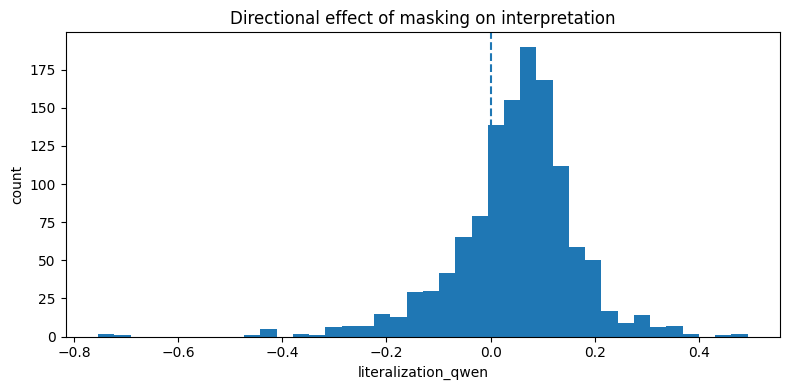

In [ ]:
#### Histogram of directional literalization
# literalization effect:  plot the distribution of directional literalization scores to see whether masking systematically shifts interpretation

x = mask_df["literalization_qwen"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8, 4))
plt.hist(x, bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("literalization_qwen")
plt.ylabel("count")
plt.title("Directional effect of masking on interpretation")
plt.tight_layout()
plt.show()

In [ ]:
#### Projection score toward literal
# Define a semantic axis from figurative to literal measure, how much masking moves output along that direction
# Positive projection shift => masked output moved toward literal meaning
# Negative projection shift => masked output moved toward figurative meaning


emb_model = SentenceTransformer(EMBED_MODEL, device=device)

def proj_toward_literal(base_txt, masked_txt, lit_txt, fig_txt):
    txts = [base_txt, masked_txt, lit_txt, fig_txt]
    V = emb_model.encode(txts, convert_to_numpy=True, normalize_embeddings=True)
    v_base, v_mask, v_lit, v_fig = V

    axis = v_lit - v_fig
    axis_norm = np.linalg.norm(axis)
    if axis_norm < 1e-12:
        return np.nan, np.nan, np.nan

    axis = axis / axis_norm

    s_base = float(np.dot(v_base, axis))
    s_mask = float(np.dot(v_mask, axis))
    shift = s_mask - s_base   # positive => toward literal

    return s_base, s_mask, shift

scores = []
for _, r in mask_df.iterrows():
    fig_txt = r["En_Equivalent"] if pd.notna(r["En_Equivalent"]) and str(r["En_Equivalent"]).strip() else r["En_Explanation"]

    s_base, s_mask, shift = proj_toward_literal(
        str(r["base_qwen"]),
        str(r["masked_qwen"]),
        str(r["En_Literal"]),
        str(fig_txt),
    )

    scores.append((s_base, s_mask, shift))

mask_df[["proj_base", "proj_mask", "proj_shift_toward_literal"]] = pd.DataFrame(scores, index=mask_df.index)
mask_df.to_csv(MASK_CSV, index=False)

print("Average proj_shift_toward_literal:", round(mask_df["proj_shift_toward_literal"].dropna().mean(), 4))
print("Percent shifts toward literal:", round((mask_df["proj_shift_toward_literal"] > 0).mean(), 3))
print("Percent shifts toward figurative:", round((mask_df["proj_shift_toward_literal"] < 0).mean(), 3))

strict = mask_df[
    (mask_df["idiom_found_as_span"] == 1) &
    (mask_df["masked_has_arabic"] == 0) &
    (mask_df["masked_is_suspicious"] == 0)
].copy()

if len(strict) > 0:
    print()
    print("STRICT SUBSET")
    print("Average proj_shift_toward_literal:", round(strict["proj_shift_toward_literal"].dropna().mean(), 4))
    print("Percent shifts toward literal:", round((strict["proj_shift_toward_literal"] > 0).mean(), 3))
    print("Percent shifts toward figurative:", round((strict["proj_shift_toward_literal"] < 0).mean(), 3))

display(
    mask_df.sort_values("proj_shift_toward_literal", ascending=False)[
        [
            "idiom",
            "idiom_word_removed_clean",
            "drift_qwen",
            "literalization_qwen",
            "proj_shift_toward_literal",
            "base_qwen",
            "masked_qwen",
            "En_Literal",
            "En_Equivalent",
        ]
    ].head(20)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Average proj_shift_toward_literal: -0.0269
Percent shifts toward literal: 0.361
Percent shifts toward figurative: 0.541

STRICT SUBSET
Average proj_shift_toward_literal: -0.0299
Percent shifts toward literal: 0.369
Percent shifts toward figurative: 0.604


,idiom,idiom_word_removed_clean,drift_qwen,literalization_qwen,proj_shift_toward_literal,base_qwen,masked_qwen,En_Literal,En_Equivalent
590,الصّديق وقت الضّيق,الصديق,0.512552,0.256547,0.392772,"The friend is there when you need him most, no...","After the experience, he said: It's during tou...",A friend is (in) the time of distress.,A friend in need is a friend indeed.
853,خير الكلام ما قلّ ودلّ,ودل,0.456092,0.280997,0.382351,"The simple statement convinced everyone, sayin...","Said one thing and convinced everyone, good wo...",The best speech is what is few and indicates (...,Less is more.
489,الأمور بخواتمها,الامور,0.442245,0.209788,0.369330,The man was anxious but reassured him: all is ...,"He was worried but reassured him: ""Take off yo...",Matters are by their endings.,All is well that ends well.
852,خير الكلام ما قلّ ودلّ,قل,0.520919,0.241438,0.343905,"The simple statement convinced everyone, sayin...","Said one thing and convinced everyone, good wo...",The best speech is what is few and indicates (...,Less is more.
1118,كما تزرع تحصد.,كما,0.305336,0.335439,0.343561,"The neglect today is natural, just as you sow ...","His neglect today is natural, planting seeds f...","As you plant, you harvest.","As you sow, so shall you reap."
278,إن الجبان حتفه من فوقه.,الجبان,0.234101,0.284796,0.336959,"He was afraid of everything, then realized tha...","He was afraid of everything, then realized tha...",The coward's death comes from above him.,the destiny of a coward comes from over him.
850,خير الكلام ما قلّ ودلّ,الكلام,0.417126,0.259923,0.316540,"The simple statement convinced everyone, sayin...","Said one thing and convinced everyone, that is...",The best speech is what is few and indicates (...,Less is more.
857,خیر الأمور أوسطھا.,خیر,0.188648,0.352480,0.308170,The middle way was chosen because the best thi...,He chose the middle way because the best thing...,The best of matters is their middle.,Everything in moderation.
859,خیر الأمور أوسطھا.,اوسطھا,0.188648,0.352480,0.308170,The middle way was chosen because the best thi...,He chose the middle way because the best thing...,The best of matters is their middle.,Everything in moderation.
976,على أحر من الجمر,علي,0.311212,0.393288,0.295033,We endured worse than fire until the news arri...,We were hotter than fire until the news came.,On hotter than embers.,On pins and needles


In [ ]:
############ Top words causing literal collaspe
#Identify words driving literal collapse: combine semantic drift with literlaization/projection scores
# to rank the idiom words whose removal has the strongest effect


# Higher collapse scores indicate that the removed word is more important for preserving the figurative interpretation

collapse_df = mask_df.copy()
collapse_df = collapse_df.dropna(subset=["drift_qwen", "literalization_qwen", "proj_shift_toward_literal"])

collapse_df["collapse_score_literalization"] = collapse_df["drift_qwen"] * collapse_df["literalization_qwen"]
collapse_df["collapse_score_projection"] = collapse_df["drift_qwen"] * collapse_df["proj_shift_toward_literal"]

summary = (
    collapse_df
    .groupby(["idiom", "idiom_word_removed_clean"], as_index=False)
    .agg(
        mean_drift_qwen=("drift_qwen", "mean"),
        mean_literalization_qwen=("literalization_qwen", "mean"),
        mean_proj_shift_toward_literal=("proj_shift_toward_literal", "mean"),
        mean_collapse_score_literalization=("collapse_score_literalization", "mean"),
        mean_collapse_score_projection=("collapse_score_projection", "mean"),
        n=("drift_qwen", "count"),
        idiom_found_rate=("idiom_found_as_span", "mean"),
    )
    .sort_values("mean_collapse_score_projection", ascending=False)
)

display(summary.head(30))

,idiom,idiom_word_removed_clean,mean_drift_qwen,mean_literalization_qwen,mean_proj_shift_toward_literal,mean_collapse_score_literalization,mean_collapse_score_projection,n,idiom_found_rate
235,الصّديق وقت الضّيق,الصديق,0.280351,0.175376,0.193750,0.063546,0.081024,3,1.000000
346,دق الحديد وهو حامي.,وهو,0.350137,0.263632,0.098297,0.134423,0.067934,3,1.000000
285,النظافة من الإيمان,النظافه,0.380868,0.085552,0.174730,0.033217,0.067457,2,1.000000
345,دق الحديد وهو حامي.,دق,0.384542,0.228927,0.115715,0.132219,0.063052,3,1.000000
339,خير الكلام ما قلّ ودلّ,ودل,0.354357,0.140606,0.086085,0.064107,0.060646,2,1.000000
159,اختلط الحابل بالنابل.,الحابل,0.329754,0.225484,0.135975,0.076604,0.054069,3,1.000000
303,الوقاية خير من العلاج/ درهم وقاية خير من قنطار...,وقايه,0.253667,0.046745,0.101091,0.013512,0.051287,2,0.000000
194,الأمور بخواتمها,الامور,0.350361,0.113046,0.118224,0.039979,0.048077,3,1.000000
30,أسمعٌ صوتا وأرى فوتا.,فوتا,0.272776,0.221254,0.142754,0.067926,0.044199,3,1.000000
439,كما تزرع تحصد.,كما,0.159796,0.259500,0.195274,0.046954,0.040727,3,1.000000
